Accuracy: 0.6883116883116883
Accuracy: 0.7705627705627706


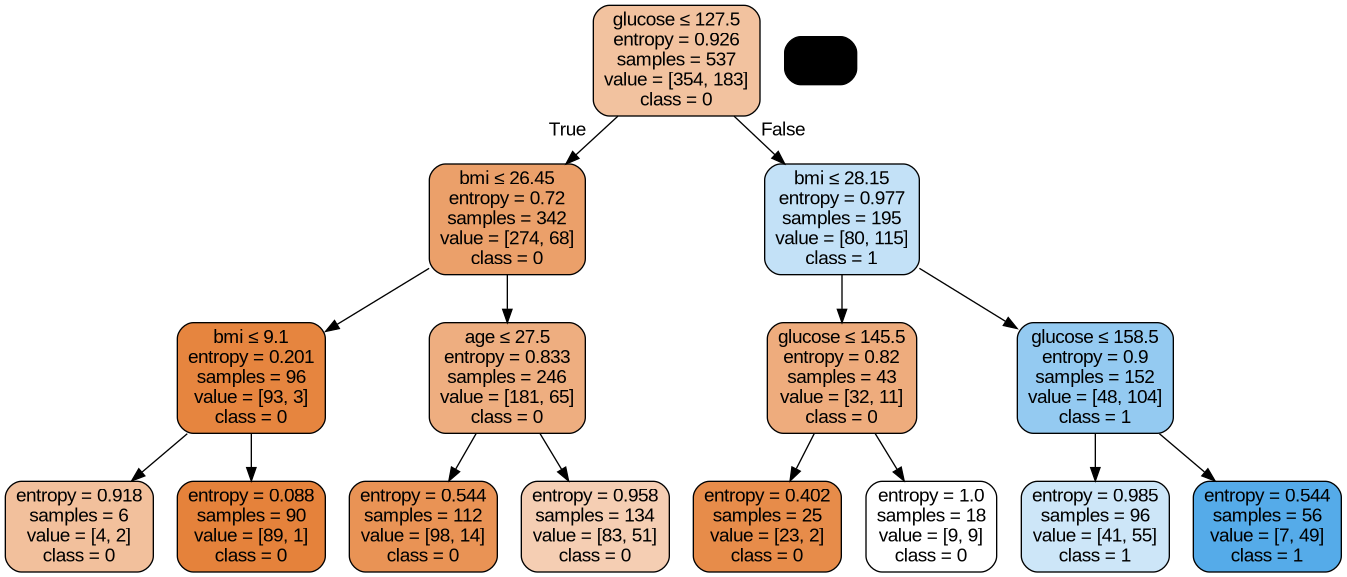

In [ ]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import DecisionTree Classifier
from sklearn.model_selection import train_test_split # Importtrain_test_split function
from sklearn import metrics #Import scikit-learn metrics module foraccuracy calculation

# Loading Data
# Let's first load the required Pima Indian Diabetes dataset usingpandas' read CSV function.
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi',
'pedigree', 'age', 'label']

# load dataset
pima = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv",
header=0, names=col_names)


pima.head()
#Feature Selection
#Here, you need to divide given columns into two types of variables
#dependent(or target variable) and independent variable(or feature
#variables).

#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi',
'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

#Splitting Data
#To understand model performance, dividing the dataset into a training set and a test set is a good strategy.
#Let's split the dataset by using function train_test_split(). You need to pass 3 parameters features, target, and test_set size.

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.3, random_state=1) # 70% training and 30% test

#Building Decision Tree Model
#Let's create a Decision Tree Model using Scikit-learn.

# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

#Evaluating Model
#Let's estimate, how accurately the classifier or model can predict the type of cultivars.
#Accuracy can be computed by comparing actual test set values and predicted values.

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
#Well, you got a classification rate of 67.53%, considered as good accuracy.

#You can improve this accuracy by tuning the parameters in the Decision Tree Algorithm.

#Visualizing Decision Trees
#You can use Scikit-learn's export_graphviz function for display the tree within a Jupyter notebook.
#For plotting tree, you also need to install graphviz and pydotplus.

!pip install graphviz

!pip install pydotplus

#export_graphviz function converts decision tree classifier into dot
#file
# and pydotplus convert this dot file to png or displayable form on
#Jupyter.

!pip install six

from six import StringIO

from sklearn.tree import export_graphviz
#from sklearn.externals.six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names =
feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())


#In the decision tree chart, each internal node has a decision rule that splits the data.
#Gini referred as Gini ratio, which measures the impurity of the node.
#You can say a node is pure when all of its records belong to the same class, such nodes known as the leaf node.
#Here, the resultant tree is unpruned. This unpruned tree is unexplainable and not easy to understand.
#In the next section, let's optimize it by pruning.

#Optimizing Decision Tree Performance

#criterion : optional (default=”gini”) or Choose attribute selection measure: This parameter allows us to use the
#different-different attribute selection measure. Supported criteria are “gini” for the Gini index and “entropy” for the information gain.

#splitter : string, optional (default=”best”) or Split Strategy: This parameter allows us to choose the split strategy.
#Supported strategies are “best” to choose the best split and “random” to choose the best random split.

#max_depth : int or None, optional (default=None) or Maximum Depth of a Tree: The maximum depth of the tree.
#If None, then nodes are expanded until all the leaves contain less than min_samples_split samples.
#The higher value of maximum depth causes overfitting, and a lower value causes underfitting (Source).

#In Scikit-learn, optimization of decision tree classifier performed by only pre-pruning.
# Maximum depth of the tree can be used as a control variable for pre-pruning.
#In the following the example, you can plot a decision tree on the same data with max_depth=3. Other than pre-pruning parameters,
#You can also try other attribute selection measure such as entropy.

# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

#Well, the classification rate increased to 77.05%, which is betteraccuracy than the previous model

#Visualizing Decision Trees

#from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names =
feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

#This pruned model is less complex, explainable, and easy to understand than the previous decision tree model plot.

In [ ]:
import pandas as pd

# Load the Salary_Data.csv file from the provided GitHub URL
df = pd.read_csv("https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Salary%20Data.csv")
df.head()

# Create the target column 'salary_more_then_100k' based on 'Salary'
df['salary_more_then_100k'] = df['Salary'].apply(lambda x: 1 if x > 100000 else 0)

# Define features (X) and target (y)
# Drop 'Salary' as it's directly related to the target and 'salary_more_then_100k' is the target itself
inputs_n = df[['Experience Years']]
target = df['salary_more_then_100k']

# inputs_n # This line seems to be a display statement. I'm keeping it as is for now.

# target # This line seems to be a display statement. I'm keeping it as is for now.

from sklearn import tree
model = tree.DecisionTreeClassifier()

model.fit(inputs_n, target)

model.score(inputs_n,target)

# Example prediction: Predict for 5 years of experience
# The model now expects a single feature: 'Experience Years'
print(f"Prediction for 5 years of experience: {model.predict([[5]])[0]}")

# Example prediction: Predict for 10 years of experience
print(f"Prediction for 10 years of experience: {model.predict([[10]])[0]}")

Prediction for 5 years of experience: 0
Prediction for 10 years of experience: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Lab Task 1: Titanic Survival Prediction using Decision Tree

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Load the Titanic dataset
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
display(titanic_df.head())

# Preprocessing: Select relevant features and drop missing values
# We'll use 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', and 'Fare' as features
features = titanic_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].droepna()

# Encode categorical 'Sex' column
le_sex = LabelEncoder()
features['Sex'] = le_sex.fit_transform(features['Sex'])

# Split into features and target
X_titanic = features.drop('Survived', axis='columns')
y_titanic = features['Survived']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier
titanic_model = DecisionTreeClassifier(max_depth=4, random_state=42)
titanic_model.fit(X_train, y_train)

# Calculate score
accuracy = titanic_model.score(X_test, y_test)
print(f"Titanic Model Accuracy Score: {accuracy:.4f}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Titanic Model Accuracy Score: 0.7552


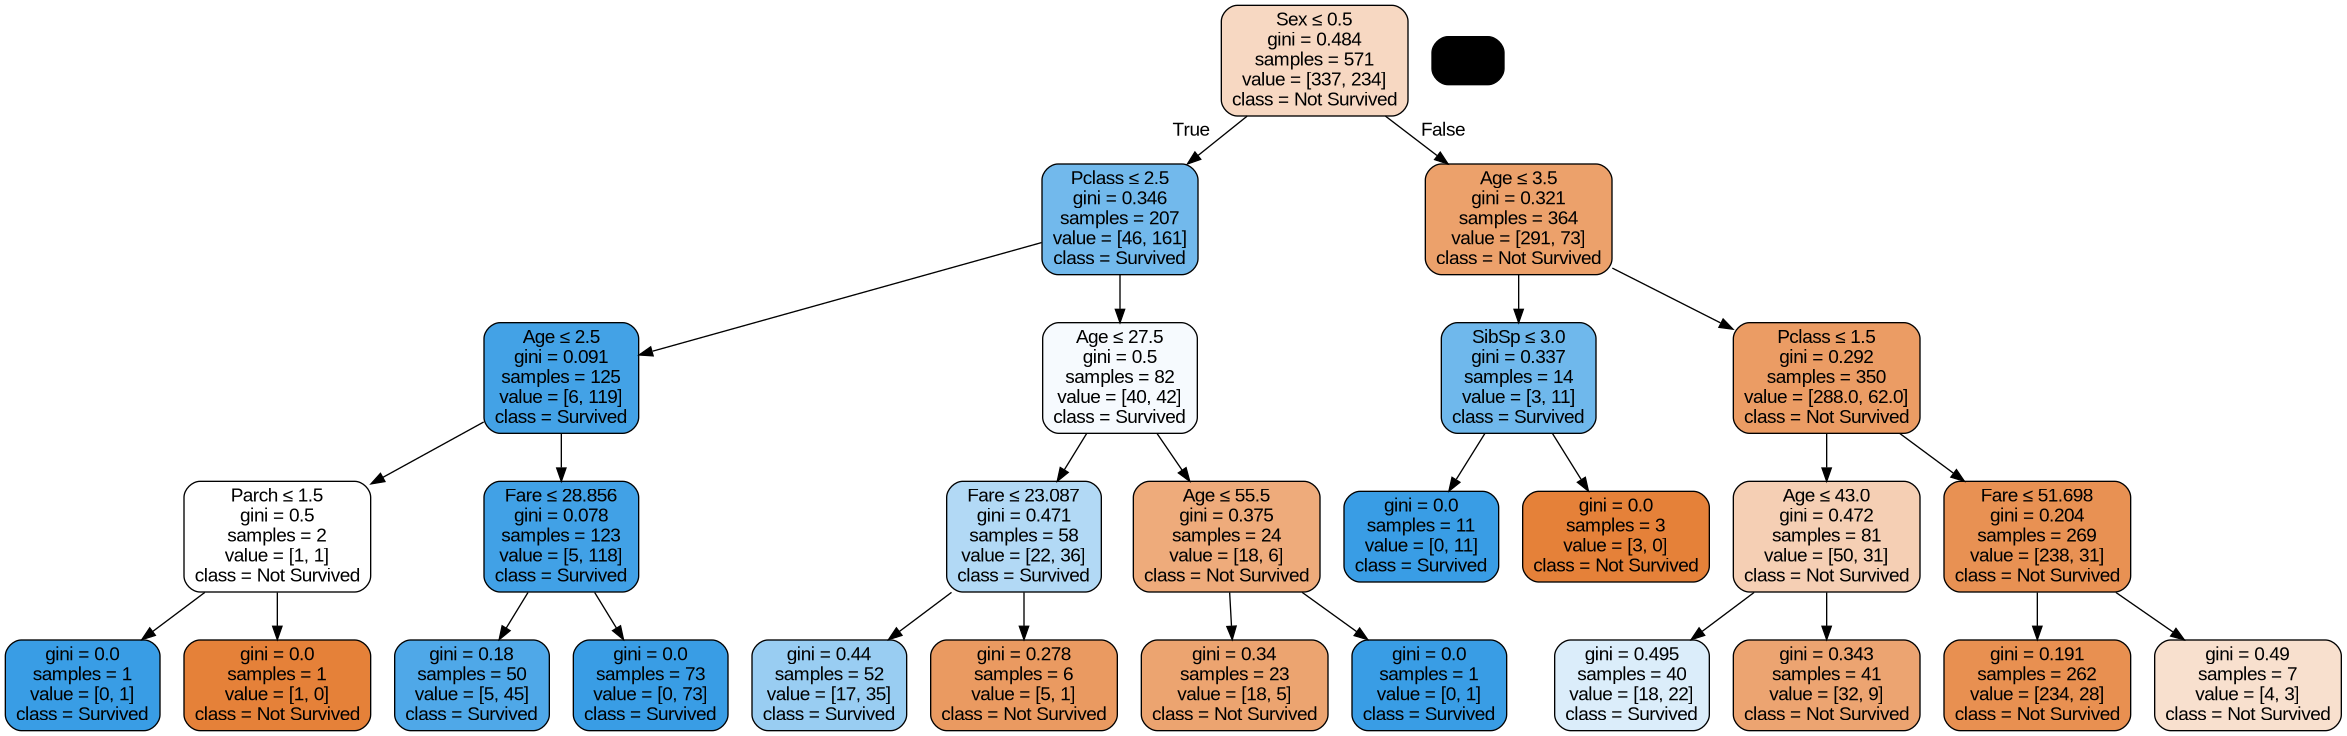

In [ ]:
from six import StringIO
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

# Visualize the Titanic Survival Decision Tree
dot_data = StringIO()
export_graphviz(
    titanic_model,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=X_titanic.columns,
    class_names=['Not Survived', 'Survived']
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('titanic_tree.png')
Image(graph.create_png())

### Lab Task 2: Car Evaluation Safety Prediction using Decision Tree

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Load the Car Evaluation dataset from UCI
# The dataset does not have headers, so we define the column names manually
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
car_df = pd.read_csv(url, names=col_names)

display(car_df.head())

# Preprocessing: Encode categorical variables
# All columns in this dataset are categorical (ordinal/nominal), so we encode them using LabelEncoder
encoders = {}
for column in car_df.columns:
    le = LabelEncoder()
    car_df[column] = le.fit_transform(car_df[column])
    encoders[column] = le

# Split into features (X) and target (y)
X_car = car_df.drop('class', axis='columns')
y_car = car_df['class']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_car, y_car, test_size=0.3, random_state=42)

# Build and train the Decision Tree Classifier
car_model = DecisionTreeClassifier(random_state=42)
car_model.fit(X_train, y_train)

# Calculate and print score
car_accuracy = car_model.score(X_test, y_test)
print(f"Car Evaluation Model Accuracy Score: {car_accuracy:.4f}")

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Car Evaluation Model Accuracy Score: 0.9711


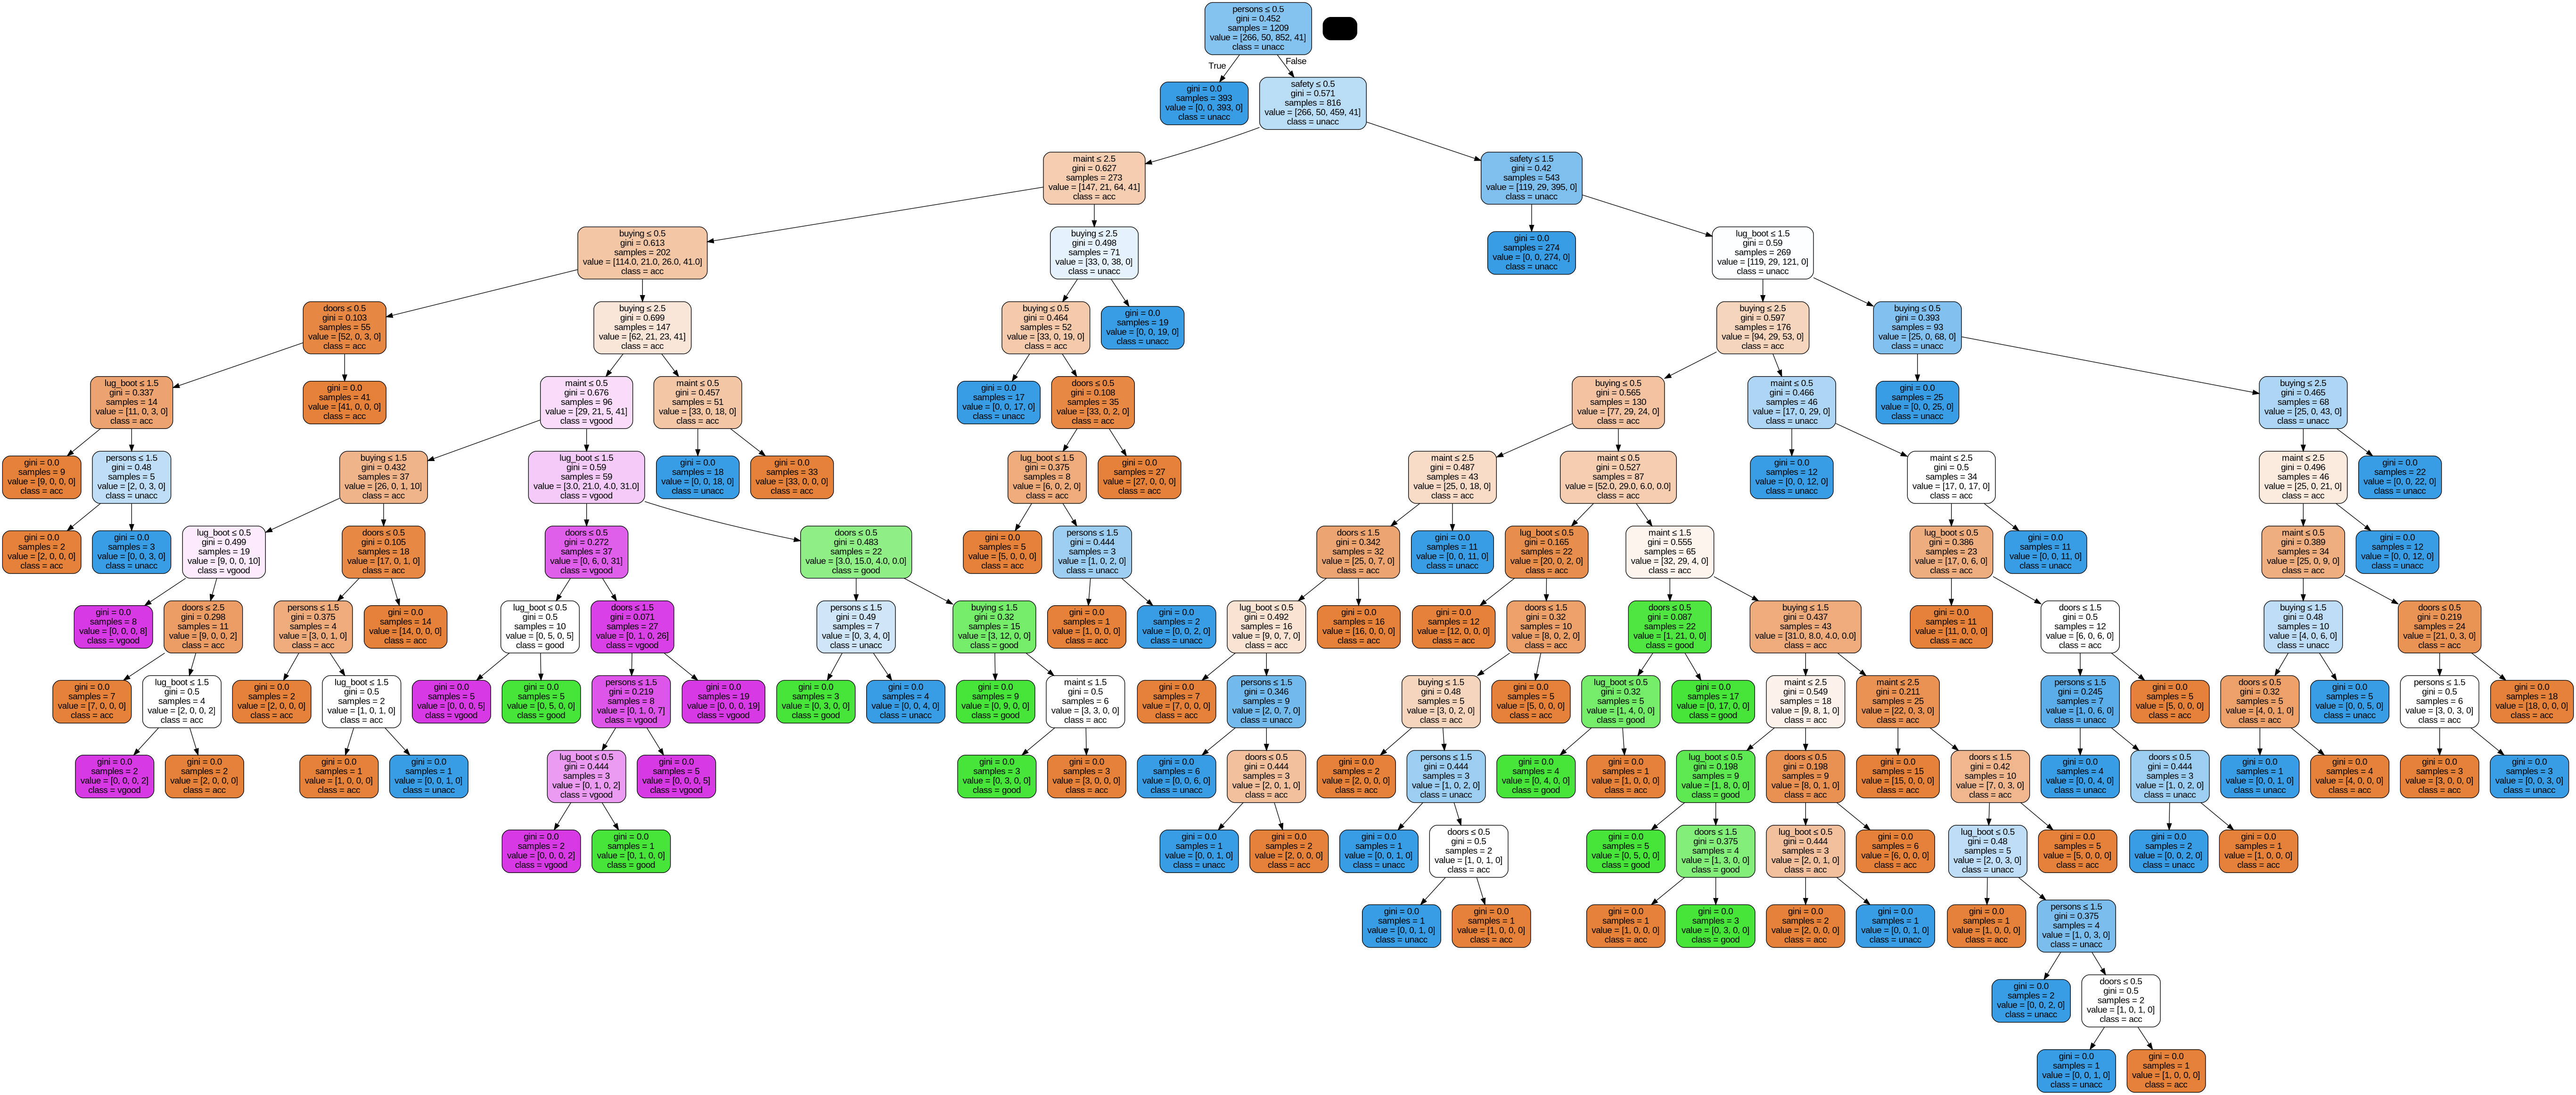

In [ ]:
from six import StringIO
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

# Visualize the Car Evaluation Decision Tree
dot_data = StringIO()
export_graphviz(
    car_model,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=X_car.columns,
    class_names=encoders['class'].classes_
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('car_evaluation_tree.png')
Image(graph.create_png())